In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('data/online_retail_II.xlsx')
display(df.head())
display(df.describe())
print(f"DataFrame shape: {df.shape}")
display(df.info())
display(df.isnull().sum())


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


DataFrame shape: (525461, 8)
<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


None

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [3]:
df.dropna(subset=['Customer ID'], inplace=True)
df['Customer ID'] = df['Customer ID'].astype(int)

### Identify and Handle Returned/Cancelled Orders

Returned or cancelled orders are typically indicated by a negative `Quantity` or `InvoiceNo` starting with 'C'. We'll separate these into a `returns_df` and remove them from the main DataFrame to ensure accurate revenue calculations.

In [4]:
# Identify returns/cancellations by negative quantity or InvoiceNo starting with 'C'
returns_df = df[(df['Quantity'] < 0) | (df['Invoice'].astype(str).str.startswith('C'))]
df = df[(df['Quantity'] >= 0) & (~df['Invoice'].astype(str).str.startswith('C'))]

print(f"Number of returned/cancelled orders: {len(returns_df)}")
print(f"Remaining orders in main DataFrame: {len(df)}")
display(returns_df.head())

Number of returned/cancelled orders: 9839
Remaining orders in main DataFrame: 407695


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321,Australia


### Check `InvoiceDate` Data Type

From `df.info()` we already know that `InvoiceDate` is `datetime64[ns]`, but it's good practice to ensure it's explicitly handled as such.

In [5]:
# Convert InvoiceDate to datetime objects if not already (df.info() shows it's already datetime64[ns])
if not pd.api.types.is_datetime64_any_dtype(df['InvoiceDate']):
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    print("InvoiceDate converted to datetime type.")
else:
    print("InvoiceDate is already datetime type.")

InvoiceDate is already datetime type.


### Remove Rows with Zero or Negative Unit Price

Transactions with `Price` <= 0 are typically free items or data entry errors and should be removed for accurate analysis.

In [6]:
# Remove rows where UnitPrice is 0 or less
initial_rows = len(df)
df = df[df['Price'] > 0]
print(f"Removed {initial_rows - len(df)} rows with Price <= 0.")

Removed 31 rows with Price <= 0.


### Remove Non-Product `StockCode` Entries

Some `StockCode` values represent non-product items (e.g., postage, samples, manual adjustments). We'll remove these to focus on actual product sales.

In [7]:
# Define common non-product StockCodes (you might need to expand this list based on data exploration)
non_product_stock_codes = [
    'POST',
    'D',
    'DOT',
    'M',
    'S',
    'AMAZONFEE',
    'CRUK',
    'BANK CHARGES',
    'C2',
    'COUPON',
    'DCGS',
    'ADJUST',
    'TEST',
    'PADS'
]

initial_rows = len(df)
df = df[~df['StockCode'].isin(non_product_stock_codes)]
print(f"Removed {initial_rows - len(df)} rows with non-product StockCodes.")

# Also remove entries where StockCode is just a letter or an empty string, if any
df = df[df['StockCode'].astype(str).str.len() > 1]
df = df[df['StockCode'].astype(str).str.strip() != '']

print(f"Final DataFrame shape after cleaning: {df.shape}")

Removed 1354 rows with non-product StockCodes.


Final DataFrame shape after cleaning: (406310, 8)


### Phase 3: Anomaly & Outlier Detection

Outliers in `Quantity` and `Price` can significantly skew analysis. This phase focuses on identifying and handling these anomalies.

#### Visual Inspection of Outliers using Box Plots

We'll use box plots to visualize the distribution of `Quantity` and `Price` and spot any apparent outliers.

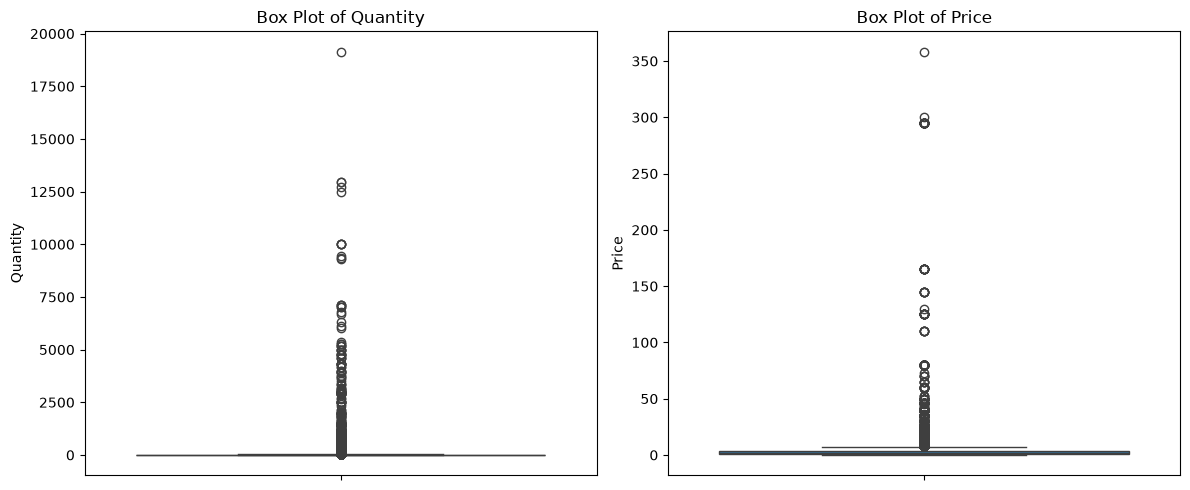

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Quantity'])
plt.title('Box Plot of Quantity')
plt.ylabel('Quantity')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Price'])
plt.title('Box Plot of Price')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

#### Quantitative Outlier Detection and Handling (IQR Method)

We will calculate the IQR for `Quantity` and `Price` to define upper and lower bounds. Values outside these bounds will be considered outliers. For handling, we'll cap these outliers at the upper bound (Q3 + 1.5 * IQR) rather than removing them entirely to retain more data.

In [9]:
# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    # In this dataset, negative quantity values were handled in cleaning, so lower bound for quantity is 0
    # For price, we already removed <=0 values, so lower bound can be considered 0 or the minimum price
    # We are primarily concerned with high outliers for revenue calculations
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

# Apply capping to 'Quantity'
print(f"Original max Quantity: {df['Quantity'].max()}")
df = cap_outliers_iqr(df.copy(), 'Quantity')
print(f"Max Quantity after capping: {df['Quantity'].max()}")

# Apply capping to 'Price'
print(f"Original max Price: {df['Price'].max()}")
df = cap_outliers_iqr(df.copy(), 'Price')
print(f"Max Price after capping: {df['Price'].max()}")

Original max Quantity: 19152
Max Quantity after capping: 27.0
Original max Price: 358.47
Max Price after capping: 7.5


#### Explanation of Outlier Handling

**Why cap instead of remove?**

Removing outliers completely can lead to loss of valuable data, especially if these extreme values represent legitimate (though rare) transactions (e.g., bulk purchases by a single customer or high-value luxury items). Capping, or winsorizing, limits the influence of extreme values without discarding the entire observation, thus preserving the overall structure and relationships in the data more effectively for RFM analysis.

#### Re-check Box Plots After Capping

Let's visualize the `Quantity` and `Price` distributions again to see the effect of capping.

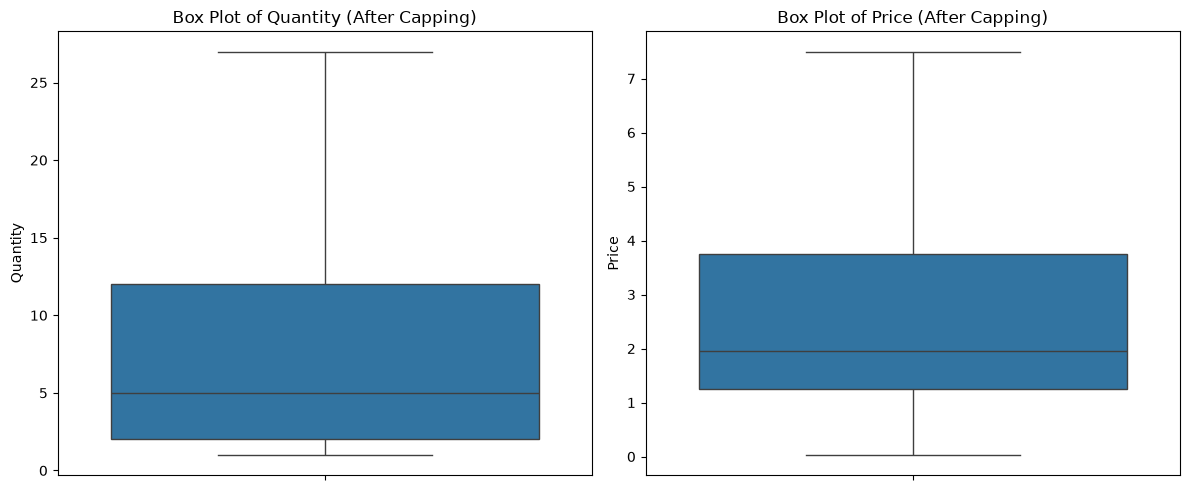

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Quantity'])
plt.title('Box Plot of Quantity (After Capping)')
plt.ylabel('Quantity')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Price'])
plt.title('Box Plot of Price (After Capping)')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

### Phase 4: Feature Engineering (The RFM Transformation)

This phase involves transforming our transactional data into a customer-centric dataset with Recency, Frequency, and Monetary (RFM) values. This is crucial for customer segmentation.

#### Calculate `TotalPrice`

First, we'll create a `TotalPrice` column by multiplying `Quantity` and `Price` for each transaction.

In [11]:
df['TotalPrice'] = df['Quantity'] * df['Price']
display(df[['Quantity', 'Price', 'TotalPrice']].head())

,Quantity,Price,TotalPrice
0,12.0,6.95,83.4
1,12.0,6.75,81.0
2,12.0,6.75,81.0
3,27.0,2.10,56.7
4,24.0,1.25,30.0


#### Determine Snapshot Date

The 'Snapshot Date' is essential for calculating Recency. It's usually set as one day after the most recent `InvoiceDate` in the dataset to ensure all transactions are included.

In [12]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot Date for RFM analysis: {snapshot_date}")

Snapshot Date for RFM analysis: 2010-12-10 20:01:00


#### Calculate Recency, Frequency, and Monetary (RFM) Values

We'll group the data by `Customer ID` to compute:
- **Recency**: Days since the last purchase (Snapshot Date - Max InvoiceDate).
- **Frequency**: Total number of unique purchases (count of unique `Invoice` numbers).
- **Monetary**: Total spending (sum of `TotalPrice`).

In [13]:
rfm_df = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

display(rfm_df.head())

,Customer ID,Recency,Frequency,Monetary
0,12346,165,11,372.86
1,12347,3,2,1297.97
2,12348,74,1,221.16
3,12349,43,2,1996.34
4,12351,11,1,295.68


#### Bonus: Calculate Customer Tenure

Tenure represents how long a customer has been active, calculated as the difference between the Snapshot Date and their *first* purchase date.

In [14]:
min_purchase_date = df.groupby('Customer ID')['InvoiceDate'].min().reset_index()
min_purchase_date.rename(columns={'InvoiceDate': 'MinPurchaseDate'}, inplace=True)

rfm_df = rfm_df.merge(min_purchase_date, on='Customer ID', how='left')
rfm_df['Tenure'] = (snapshot_date - rfm_df['MinPurchaseDate']).dt.days

# Drop the intermediate MinPurchaseDate column
rfm_df.drop(columns=['MinPurchaseDate'], inplace=True)

display(rfm_df.head())

,Customer ID,Recency,Frequency,Monetary,Tenure
0,12346,165,11,372.86,361
1,12347,3,2,1297.97,40
2,12348,74,1,221.16,74
3,12349,43,2,1996.34,225
4,12351,11,1,295.68,11


### Phase 5: Pipeline Finalization & Handoff

This final phase encapsulates all the data preparation steps into a reusable function, tests its integrity, and prepares the final customer-level RFM dataset for downstream use.

#### Wrap Cleaning and RFM Steps into a Function

We'll create a function `prep_ecommerce_data` that takes the raw data file path, performs all the cleaning, outlier handling, and RFM feature engineering steps, and returns the final `rfm_df`.

In [15]:
def prep_ecommerce_data(filepath):
    """
    Loads, cleans, and prepares e-commerce transactional data for RFM analysis.

    Args:
        filepath (str): Path to the Excel file containing the raw transactional data.

    Returns:
        pandas.DataFrame: A DataFrame with Customer ID, Recency, Frequency, Monetary, and Tenure.
    """
    # 1. Load data
    df = pd.read_excel(filepath)

    # 2. Data Cleaning
    # Drop rows where CustomerID is missing
    df.dropna(subset=['Customer ID'], inplace=True)
    df['Customer ID'] = df['Customer ID'].astype(int)

    # Remove returns/cancellations
    df = df[(df['Quantity'] >= 0) & (~df['Invoice'].astype(str).str.startswith('C'))]

    # Ensure InvoiceDate is datetime
    if not pd.api.types.is_datetime64_any_dtype(df['InvoiceDate']):
        df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

    # Remove rows where Price is 0 or less
    df = df[df['Price'] > 0]

    # Remove non-product StockCodes
    non_product_stock_codes = [
        'POST', 'D', 'DOT', 'M', 'S', 'AMAZONFEE', 'CRUK', 'BANK CHARGES',
        'C2', 'COUPON', 'DCGS', 'ADJUST', 'TEST', 'PADS'
    ]
    df = df[~df['StockCode'].isin(non_product_stock_codes)]
    df = df[df['StockCode'].astype(str).str.len() > 1]
    df = df[df['StockCode'].astype(str).str.strip() != '']

    # 3. Anomaly & Outlier Detection (Capping using IQR)
    def cap_outliers_iqr(df_col, column):
        Q1 = df_col[column].quantile(0.25)
        Q3 = df_col[column].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        # In this dataset, negative quantity values were handled in cleaning, so lower bound for quantity is 0
        # For price, we already removed <=0 values, so lower bound can be considered 0 or the minimum price
        df_col[column] = np.where(df_col[column] > upper_bound, upper_bound, df_col[column])
        return df_col

    df = cap_outliers_iqr(df.copy(), 'Quantity')
    df = cap_outliers_iqr(df.copy(), 'Price')

    # 4. Feature Engineering (RFM Transformation)
    df['TotalPrice'] = df['Quantity'] * df['Price']
    snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

    # Calculate RFM
    rfm_df = df.groupby('Customer ID').agg(
        Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
        Frequency=('Invoice', 'nunique'),
        Monetary=('TotalPrice', 'sum')
    ).reset_index()

    # Calculate Tenure (Bonus)
    min_purchase_date = df.groupby('Customer ID')['InvoiceDate'].min().reset_index()
    min_purchase_date.rename(columns={'InvoiceDate': 'MinPurchaseDate'}, inplace=True)
    rfm_df = rfm_df.merge(min_purchase_date, on='Customer ID', how='left')
    rfm_df['Tenure'] = (snapshot_date - rfm_df['MinPurchaseDate']).dt.days
    rfm_df.drop(columns=['MinPurchaseDate'], inplace=True)

    return rfm_df

print("Function `prep_ecommerce_data` defined.")

Function `prep_ecommerce_data` defined.


#### Run the Pipeline Function and Check Output

Let's run the newly created function with the raw data file and inspect the resulting `rfm_customer_data` DataFrame.

In [16]:
rfm_customer_data = prep_ecommerce_data('data/online_retail_II.xlsx')

print("First 5 rows of the RFM Customer Data:")
display(rfm_customer_data.head())

print("Information about the RFM Customer Data DataFrame:")
rfm_customer_data.info()

print("Missing values in RFM Customer Data:")
display(rfm_customer_data.isnull().sum())

First 5 rows of the RFM Customer Data:


,Customer ID,Recency,Frequency,Monetary,Tenure
0,12346,165,11,372.86,361
1,12347,3,2,1297.97,40
2,12348,74,1,221.16,74
3,12349,43,2,1996.34,225
4,12351,11,1,295.68,11


Information about the RFM Customer Data DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 4285 entries, 0 to 4284
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  4285 non-null   int64  
 1   Recency      4285 non-null   int64  
 2   Frequency    4285 non-null   int64  
 3   Monetary     4285 non-null   float64
 4   Tenure       4285 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 167.5 KB
Missing values in RFM Customer Data:


Customer ID    0
Recency        0
Frequency      0
Monetary       0
Tenure         0
dtype: int64

#### Export the Final DataFrame to CSV

Now, we'll save the `rfm_customer_data` DataFrame to a CSV file for easy sharing and further analysis by other team members.

In [17]:
output_filename = 'rfm_customer_data.csv'
rfm_customer_data.to_csv(output_filename, index=False)
print(f"RFM customer data exported successfully to '{output_filename}'.")

RFM customer data exported successfully to 'rfm_customer_data.csv'.


#### Data Dictionary for `rfm_customer_data.csv`

This explains the columns in the exported CSV file for your team members.

-   **Customer ID**: Unique identifier for each customer.
-   **Recency**: Number of days since the customer's last purchase. A lower number indicates a more recent customer.
-   **Frequency**: Total number of unique purchases made by the customer. A higher number indicates a more frequent customer.
-   **Monetary**: Total amount of money spent by the customer. A higher number indicates a higher-value customer.
-   **Tenure**: Number of days since the customer's first purchase. Represents how long the customer has been active.